In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmocean as cm
import gsw
import pandas as pd

In [2]:
err = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output.abort.up2021main.nc")
err

<xarray.Dataset> Size: 413MB
Dimensions:       (time_counter: 1, deptht: 40, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2021-07-24T00:00:40
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
    nav_lon       (y, x) float32 1MB ...
    nav_lat       (y, x) float32 1MB ...
Dimensions without coordinates: y, x
Data variables: (12/14)
    vosaline      (time_counter, deptht, y, x) float32 57MB ...
    votemper      (time_counter, deptht, y, x) float32 57MB ...
    sossheig      (time_counter, y, x) float32 1MB ...
    vozocrtx      (time_counter, deptht, y, x) float32 57MB ...
    vomecrty      (time_counter, deptht, y, x) float32 57MB ...
    vovecrtz      (time_counter, deptht, y, x) float32 57MB ...
    ...            ...
    soshfldo      (time_counter, y, x) float32 1MB ...
    soicecov      (time_counter, y, x) float32 1MB ...
    sozotaux      (time_counter, y, x) float32 1MB ...
    sometauy      (time_counter, y, x) float32 1MB ...
    vovvldep      (time_counter, deptht, y, x) float32 57MB ...
    vovvle3t      (time_counter, deptht, y, x) float32 57MB ...
Attributes:
    Conventions:  CF-1.1
    production:   An IPSL model
    TimeStamp:    13/09/2026 08:32:52 -0700
    file_name:    output.abort.nc

In [3]:
ssh = err.sossheig.values[0,:,:]
print(np.nanmax(ssh))
print(np.argmax(ssh))

inf
129250


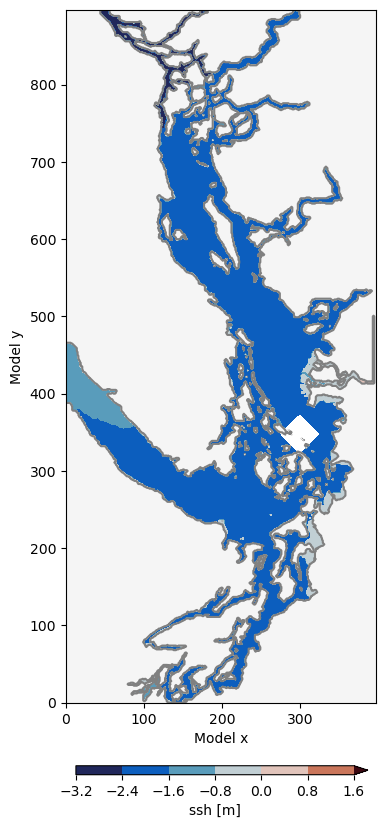

In [4]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
grid = xr.open_dataset("/home/sallen/MEOPAR/grid/bathymetry_202108.nc", mask_and_scale=False)

# Make plot area
fig, ax = plt.subplots(figsize=(4, 9))

# Depth
c = ax.contourf(
    grid.x, grid.y, ssh, vmax=3, vmin=-3,
    cmap=cm.cm.balance, extend='max', zorder=1,
)
cax = fig.add_axes([0.15, 0.03, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal',label='ssh [m]')

ax.set_xlabel("Model x")
ax.set_ylabel("Model y")

# Draw coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

## problem at the JdF boundary

In [6]:
def get_depth_profile(df, date_str):
    row = df.loc[df["day"] == date_str]
    prof = row.select_dtypes(include=np.number).to_numpy().squeeze()
    return prof  # shape (40,)

In [16]:
bins = np.append(mesh.gdepw_1d.values[0],mesh.gdepw_1d.values[0][-1]+mesh.e3w_1d.values[0][-1])
bins

array([  0.        ,   1.00000123,   2.00000639,   3.00001921,
         4.00004695,   5.00010374,   6.00021712,   7.00044072,
         8.00087898,   9.00173537,  10.00340608,  11.00666275,
        12.01300785,  13.02536622,  14.04942854,  15.09625559,
        16.18730348,  17.36403385,  18.7059723 ,  20.36347338,
        22.61306387,  25.93741305,  31.10103509,  39.1188566 ,
        50.96323669,  67.05207424,  86.96747037, 109.73706598,
       134.34593444, 160.02956159, 186.30527815, 212.89655735,
       239.65304462, 266.49521437, 293.38160496, 320.29076029,
       347.21161956, 374.1384921 , 401.06845307, 428.        ,
       454.93204325])

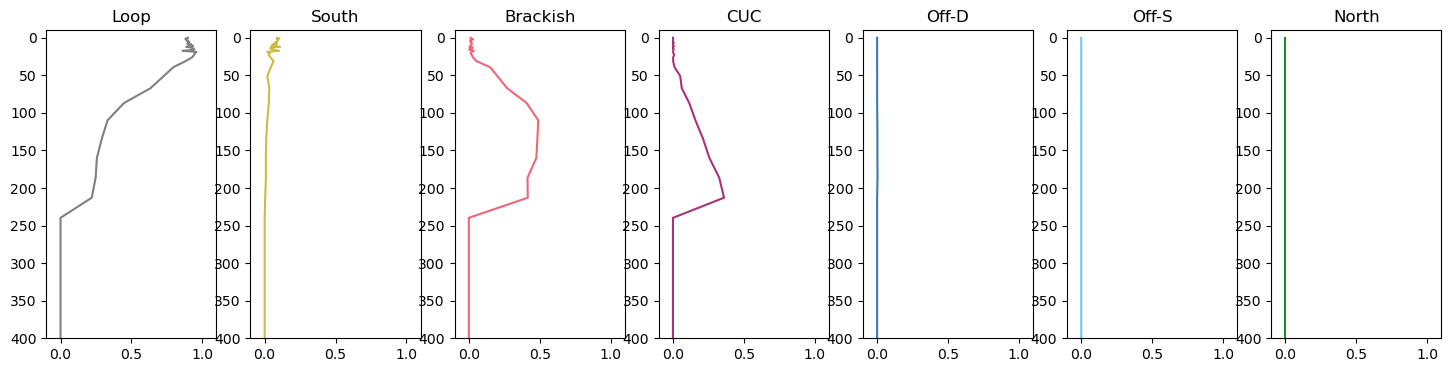

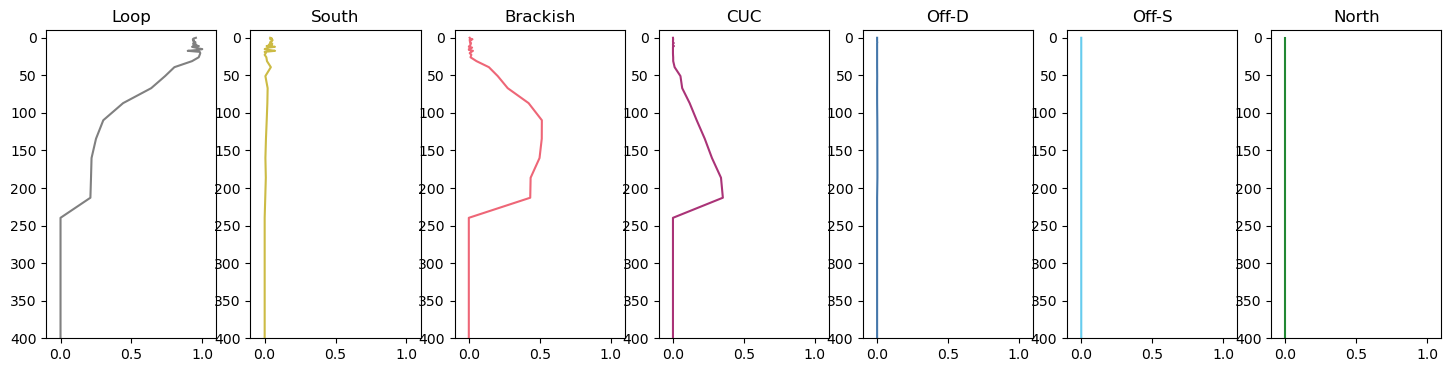

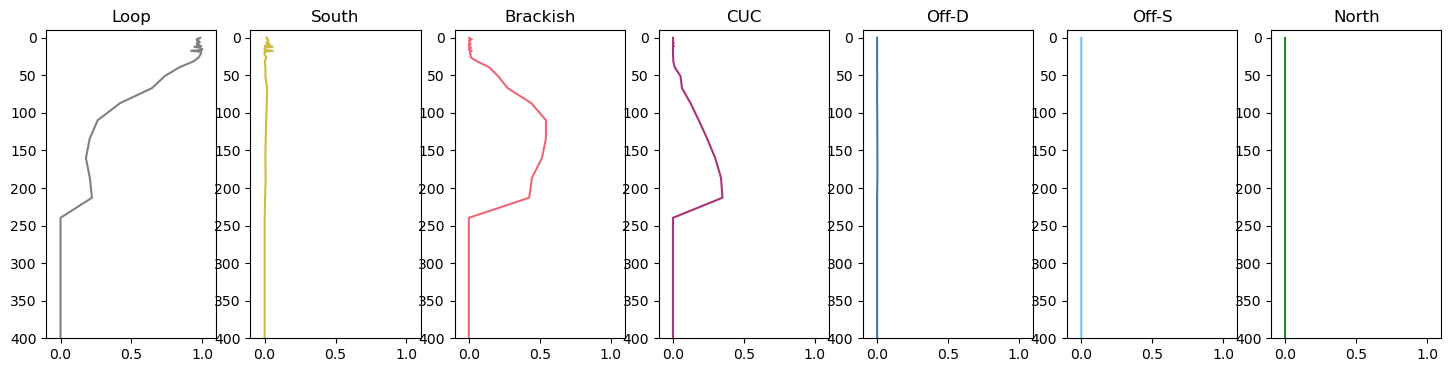

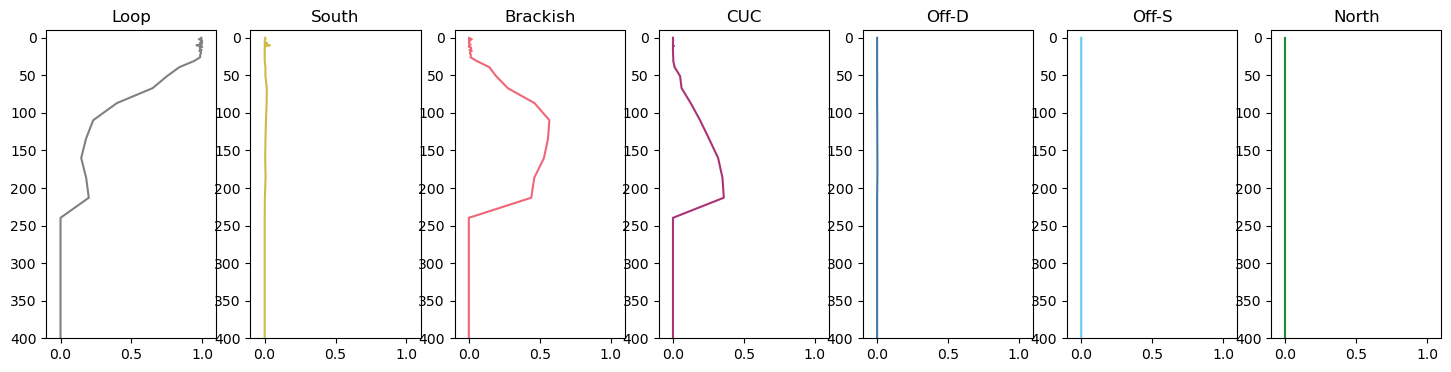

In [22]:
# 13/02/2021 is the error day, lets look there, two days before, and one day after 

df_loop = pd.read_csv("./output/inflowfraction_D_loop.csv").drop(columns='Unnamed: 0')
df_fresh = pd.read_csv("./output/inflowfraction_D_fresh.csv").drop(columns='Unnamed: 0')
df_south = pd.read_csv("./output/inflowfraction_D_south.csv").drop(columns='Unnamed: 0')
df_cuc = pd.read_csv("./output/inflowfraction_D_cuc.csv").drop(columns='Unnamed: 0')
df_offD = pd.read_csv("./output/inflowfraction_D_offD.csv").drop(columns='Unnamed: 0')
df_offS = pd.read_csv("./output/inflowfraction_D_offS.csv").drop(columns='Unnamed: 0')
df_north = pd.read_csv("./output/inflowfraction_D_north.csv").drop(columns='Unnamed: 0')

datesample=['2021-02-11','2021-02-12','2021-02-13','2021-02-14']

for datestr in datesample:
    fig, ax = plt.subplots(1,7, figsize=(18,4))

    ax[0].plot(get_depth_profile(df_loop,datestr),bins[:-1],color="grey")
    ax[0].set_title('Loop')
    ax[1].plot(get_depth_profile(df_fresh,datestr),bins[:-1],color="#CCBB44")
    ax[1].set_title('South')
    ax[2].plot(get_depth_profile(df_south,datestr),bins[:-1],color="#EE6677")
    ax[2].set_title('Brackish')
    ax[3].plot(get_depth_profile(df_cuc,datestr),bins[:-1],color="#AA3377")
    ax[3].set_title('CUC')
    ax[4].plot(get_depth_profile(df_offD,datestr),bins[:-1],color="#4477AA")
    ax[4].set_title('Off-D')
    ax[5].plot(get_depth_profile(df_offS,datestr),bins[:-1],color="#66CCEE")
    ax[5].set_title('Off-S')
    ax[6].plot(get_depth_profile(df_north,datestr),bins[:-1],color="#228833")
    ax[6].set_title('North')

    for axs in ax:  
        axs.set_ylim([400,-10])
        axs.set_xlim(-0.1,1.1)
    plt.tight_layout    

## cross sections at the boundary

In [69]:
# build an easily editable tracer dictionary 

data = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/SalishSea_1d_20210101_20211231_pri_T_20210212-20210212.nc')

fail = {
    "salt":      np.where(data["vosaline"][0,:,380:470,5].values.copy()==0, np.nan, data["vosaline"][0,:,380:470,5].values.copy()),
    "temp":      np.where(data["votemper"][0,:,380:470,5].values.copy()==0, np.nan, data["votemper"][0,:,380:470,5].values.copy())
}

data = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/13feb21/SalishSea_1d_20210213_20210213_grid_T.nc')

oldy = {
    "salt":       np.where(data["vosaline"][0,:,380:470,5].values.copy()==0, np.nan, data["vosaline"][0,:,380:470,5].values.copy()),
    "temp":       np.where(data["votemper"][0,:,380:470,5].values.copy()==0, np.nan, data["votemper"][0,:,380:470,5].values.copy())
}

In [70]:
# add density
fail['sigma0'] = gsw.density.sigma0(fail['salt'],fail['temp'])
oldy['sigma0'] = gsw.density.sigma0(oldy['salt'],oldy['temp'])

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

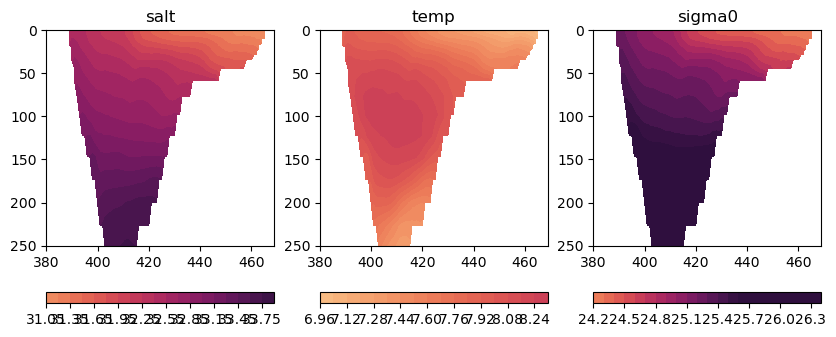

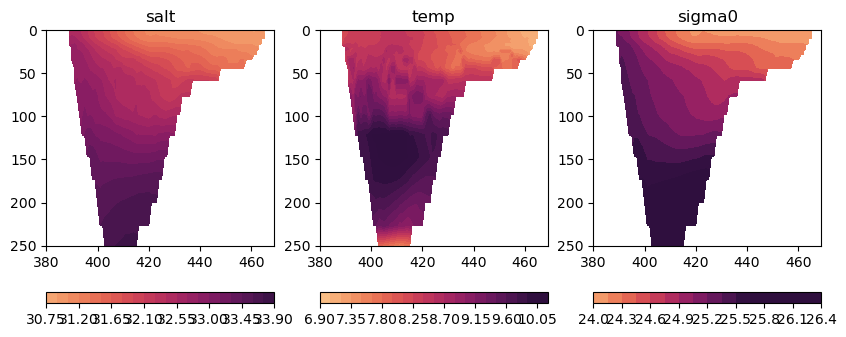

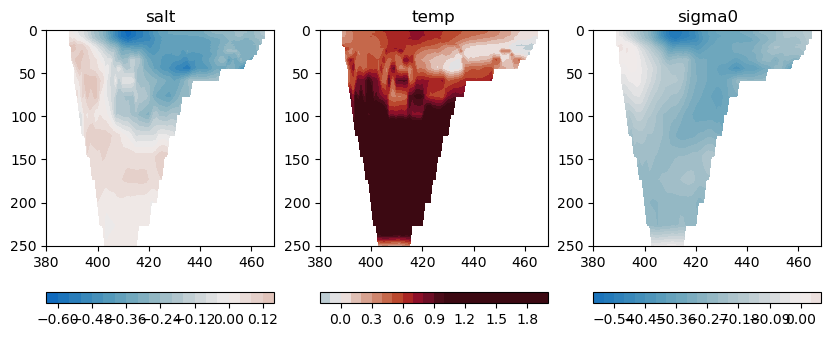

In [72]:
# ORIGINAL
X, Y = np.meshgrid(data.y[380:470].values,data.deptht.values)
tracers = ['salt','temp','sigma0']
vmin = [30,6.5,23.6]
vmax = [34,10,25.6]

fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = oldy[tracers[i]]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# PROJECTION
fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = fail[tracers[i]]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# DIFFERENCE
fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = fail[tracers[i]] - oldy[tracers[i]]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=-1,vmax=1)
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout
